<a href="https://colab.research.google.com/github/plexisad/CS531ML_Learning/blob/main/Mini_Project_Data_Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Jeff Legg, Shawn Healy and Matthew Reyes

CS 536 Intro to Machine Learning

Mini Project Milestone 2

In [18]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Make plots look a little nicer
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("open-source-sports/baseball-databank")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'baseball-databank' dataset.
Path to dataset files: /kaggle/input/baseball-databank


# 1. Dataset Overview

**Dataset Name:** Baseball Databank

**Dataset Source:** Kaggle (`open-source-sports/baseball-databank`)

**Number of Samples:** The raw `Batting.csv` table contains approximately 101,332 player-season rows. After merging `Batting`, `Pitching`, and `Salaries` on `(playerID, yearID, teamID)`, the analysis dataset used below (`baseball`) has 101364 rows. Salaries table only begins in 1985, so many early player-seasons have no salary at all (see Table 1).

**Number of Features:** `Batting.csv` has 22 columns, `Pitching.csv` has 30 columns, and `Salaries.csv` has 5 columns. After merging (and dropping duplicate join keys), the combined dataset has 49 columns.

**Target Variable:** `salary` (continuous)

**Machine Learning Task:** This is a regression task. We use player performance statistics (batting and pitching stats) to predict a player's salary for a given season.


In [7]:
batting = pd.read_csv(f"{path}/Batting.csv")
pitching = pd.read_csv(f"{path}/Pitching.csv")
salaries = pd.read_csv(f"{path}/Salaries.csv")

print(batting.shape)
print(pitching.shape)
print(salaries.shape)

(101332, 22)
(44139, 30)
(25575, 5)


In [8]:
print(batting.columns.tolist())
print(pitching.columns.tolist())
print(salaries.columns.tolist())

['playerID', 'yearID', 'stint', 'teamID', 'lgID', 'G', 'AB', 'R', 'H', '2B', '3B', 'HR', 'RBI', 'SB', 'CS', 'BB', 'SO', 'IBB', 'HBP', 'SH', 'SF', 'GIDP']
['playerID', 'yearID', 'stint', 'teamID', 'lgID', 'W', 'L', 'G', 'GS', 'CG', 'SHO', 'SV', 'IPouts', 'H', 'ER', 'HR', 'BB', 'SO', 'BAOpp', 'ERA', 'IBB', 'WP', 'HBP', 'BK', 'BFP', 'GF', 'R', 'SH', 'SF', 'GIDP']
['yearID', 'teamID', 'lgID', 'playerID', 'salary']


In [9]:
bat_pitch = batting.merge(
    pitching,
    on=["playerID", "yearID", "teamID"],
    how="left",
    suffixes=("_bat", "_pit")
)

print(bat_pitch.shape)

(101364, 49)


In [10]:
baseball = bat_pitch.merge(
    salaries,
    on=["playerID", "yearID", "teamID"],
    how="left"
)

print(baseball.shape)
baseball.head()

(101364, 51)


,playerID,yearID,stint_bat,teamID,lgID_bat,G_bat,AB,R_bat,H_bat,2B,...,HBP_pit,BK,BFP,GF,R_pit,SH_pit,SF_pit,GIDP_pit,lgID,salary
0,abercda01,1871,1,TRO,NaN,1,4.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,addybo01,1871,1,RC1,NaN,25,118.0,30.0,32.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,allisar01,1871,1,CL1,NaN,29,137.0,28.0,40.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,allisdo01,1871,1,WS3,NaN,27,133.0,28.0,44.0,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ansonca01,1871,1,RC1,NaN,25,120.0,29.0,39.0,11.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
baseball.tail()

,playerID,yearID,stint_bat,teamID,lgID_bat,G_bat,AB,R_bat,H_bat,2B,...,HBP_pit,BK,BFP,GF,R_pit,SH_pit,SF_pit,GIDP_pit,lgID,salary
101359,zitoba01,2015,1,OAK,AL,3,0.0,0.0,0.0,0.0,...,0.0,0.0,37.0,1.0,8.0,0.0,0.0,NaN,NaN,NaN
101360,zobribe01,2015,1,OAK,AL,67,235.0,39.0,63.0,20.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AL,7500000.0
101361,zobribe01,2015,2,KCA,AL,59,232.0,37.0,66.0,16.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
101362,zuninmi01,2015,1,SEA,AL,112,350.0,28.0,61.0,11.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AL,523500.0
101363,zychto01,2015,1,SEA,AL,13,0.0,0.0,0.0,0.0,...,2.0,0.0,76.0,4.0,6.0,0.0,0.0,NaN,NaN,NaN


##Exploratory Data Analysis

In [12]:
print(f"Dataset Shape: {baseball.shape}")

baseball.info()

Dataset Shape: (101364, 51)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101364 entries, 0 to 101363
Data columns (total 51 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   playerID   101364 non-null  object 
 1   yearID     101364 non-null  int64  
 2   stint_bat  101364 non-null  int64  
 3   teamID     101364 non-null  object 
 4   lgID_bat   100627 non-null  object 
 5   G_bat      101364 non-null  int64  
 6   AB         96215 non-null   float64
 7   R_bat      96215 non-null   float64
 8   H_bat      96215 non-null   float64
 9   2B         96215 non-null   float64
 10  3B         96215 non-null   float64
 11  HR_bat     96215 non-null   float64
 12  RBI        95791 non-null   float64
 13  SB         94914 non-null   float64
 14  CS         72753 non-null   float64
 15  BB_bat     96215 non-null   float64
 16  SO_bat     88377 non-null   float64
 17  IBB_bat    59643 non-null   float64
 18  HBP_bat    93403 non-null   float64


##Table 1: Missing Value Summary
This table lists every column with at least one missing value, along with the count and percentage missing, sorted from most to least missing.


In [13]:
missing_counts = baseball.isnull().sum()
missing_percent = (missing_counts / len(baseball) * 100).round(2)

missing_summary = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing %": missing_percent
})

# Only keep columns that actually have missing values, sorted by severity
missing_summary = missing_summary[missing_summary["Missing Count"] > 0].sort_values(
    "Missing %", ascending=False
)

missing_summary

,Missing Count,Missing %
GIDP_pit,100618,99.26
SH_pit,90117,88.90
SF_pit,90117,88.90
lgID,76730,75.70
salary,76730,75.70
IBB_pit,71782,70.82
BAOpp,58727,57.94
HBP_pit,57755,56.98
BFP,57436,56.66
WP,57328,56.56


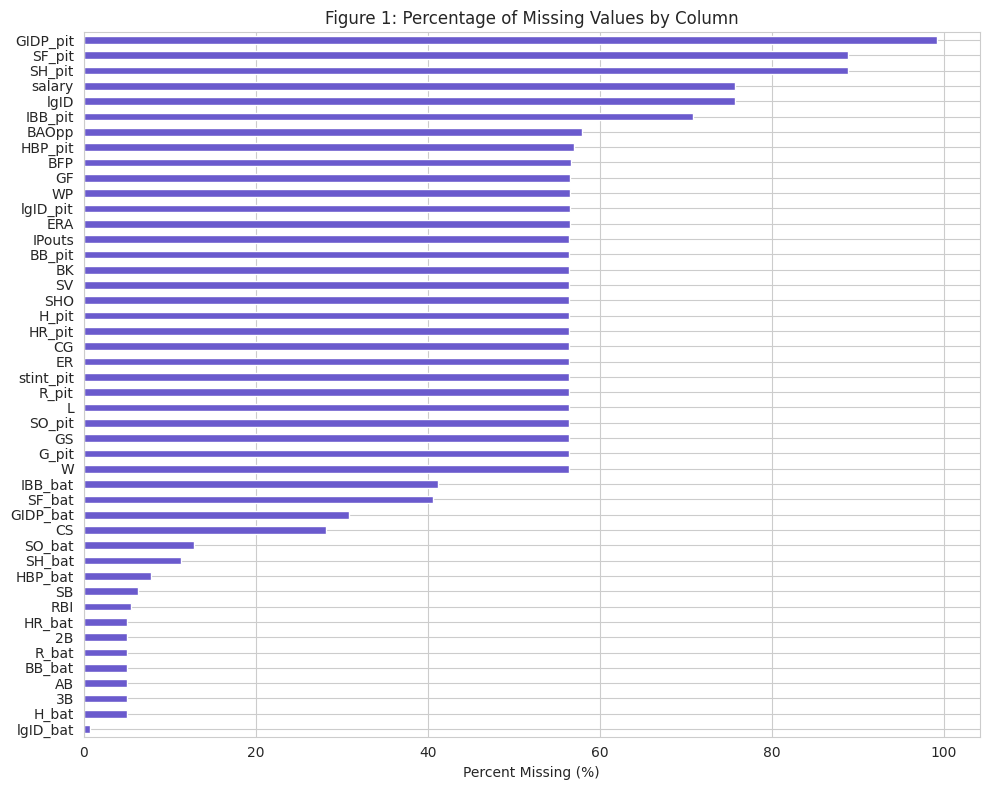

In [19]:
plt.figure(figsize=(10, 8))
missing_summary["Missing %"].sort_values().plot(kind="barh", color="slateblue")
plt.xlabel("Percent Missing (%)")
plt.title("Figure 1: Percentage of Missing Values by Column")
plt.tight_layout()
plt.show()

###Summary
There is heavy data missing because some players never pitched and salary data is not available until 1985. Meaning that in reality on 25% of the data has salary data available.

Columns such as GIDP_pit are missing > 99% of the data and will need to be dropped as well.

## Table 2: Summary Statistics of Key Numeric Features

In [21]:
import pandas as pd

summary = baseball.describe().T

# Add the median
summary["Median"] = baseball.median(numeric_only=True)

# Remove columns you don't want
summary = summary.drop(columns=["count", "25%", "50%", "75%"])

# Reorder columns
summary = summary[[
    "mean",
    "Median",
    "std",
    "min",
    "max"
]]

# Rename columns
summary = summary.rename(columns={
    "mean": "Mean",
    "Median": "Median",
    "std": "Standard Deviation",
    "min": "Minimum",
    "max": "Maximum"
})

summary

,Mean,Median,Standard Deviation,Minimum,Maximum
yearID,1.963505e+03,1972.00,3.862989e+01,1871.0,2015.00
stint_bat,1.077888e+00,1.00,2.848419e-01,1.0,5.00
G_bat,5.138773e+01,34.00,4.714331e+01,0.0,165.00
AB,1.499242e+02,57.00,1.865435e+02,0.0,716.00
R_bat,1.988078e+01,5.00,2.866869e+01,0.0,192.00
H_bat,3.924931e+01,11.00,5.330643e+01,0.0,262.00
2B,6.634984e+00,1.00,9.800612e+00,0.0,67.00
3B,1.372956e+00,0.00,2.710199e+00,0.0,36.00
HR_bat,2.948345e+00,0.00,6.408815e+00,0.0,73.00
RBI,1.795941e+01,4.00,2.675391e+01,0.0,191.00


###Summary
This table reports the mean, median, standard deviation, minimum, and maximum for every numeric column.

Some salary analysis -

Mean salary: 2,035,440 vs Median: 560,000 — the mean is over 3.6x the median.

Std dev is at 3.3 million and larger than the mean.

Max is at 33 million vs a median of 560,000 this is over 59x spread typical to max.

## Data Visualization

###Figure 2: Distribution of Home Runs and Player Salaries

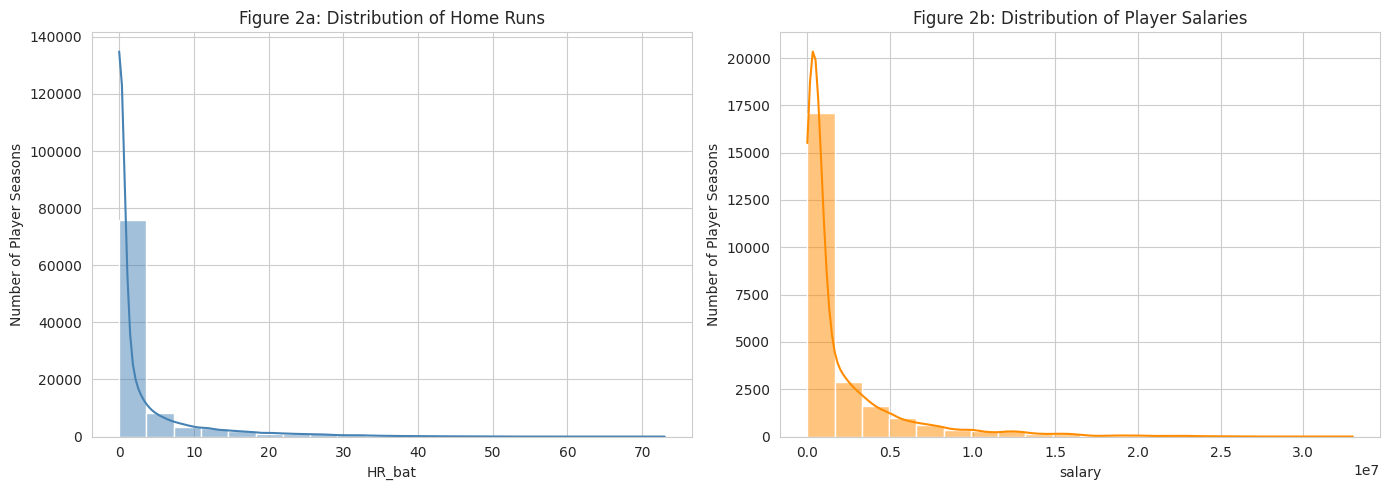

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

features = ["HR_bat", "salary"]
titles = [
    "Figure 2a: Distribution of Home Runs",
    "Figure 2b: Distribution of Player Salaries"
]
colors = ["steelblue", "darkorange"]

for ax, feature, title, color in zip(axes, features, titles, colors):
    sns.histplot(
        data=baseball.dropna(subset=[feature]),
        x=feature,
        bins=20,
        kde=True,
        color=color,
        ax=ax
    )

    ax.set_title(title)
    ax.set_xlabel(feature)
    ax.set_ylabel("Number of Player Seasons")

plt.tight_layout()
plt.show()

#### Summary

We see that in both of these histograms the data is right-skewed and the shape of the two distributions is similar. The majority of players seasons are close to 0 home runs and a small salary. This right-skew in salary is the primary supporting evidence for Hypothesis 2.

###Figure 3: Distribution of Hits and Wins

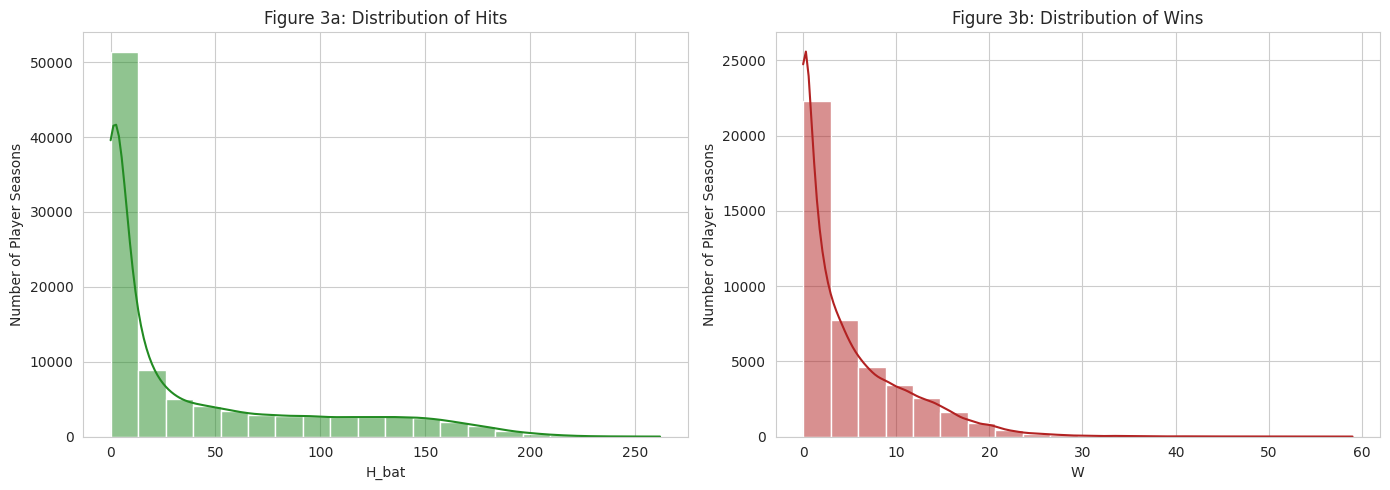

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

features = ["H_bat", "W"]
titles = [
    "Figure 3a: Distribution of Hits",
    "Figure 3b: Distribution of Wins"
]
colors = ["forestgreen", "firebrick"]

for ax, feature, title, color in zip(axes, features, titles, colors):
    sns.histplot(
        data=baseball,
        x=feature,
        bins=20,
        kde=True,
        color=color,
        ax=ax
    )

    ax.set_title(title)
    ax.set_xlabel(feature)
    ax.set_ylabel("Number of Player Seasons")

plt.tight_layout()
plt.show()

####Summary

We see a similar skewing in figure 3 with both hits and wins. The majority of players seasons are low with a long tail of small high performance seasons. This pattern is data wide it seems.

###Figure 4: Distribution of Earned Run Average (ERA) and Pitching Strikeouts

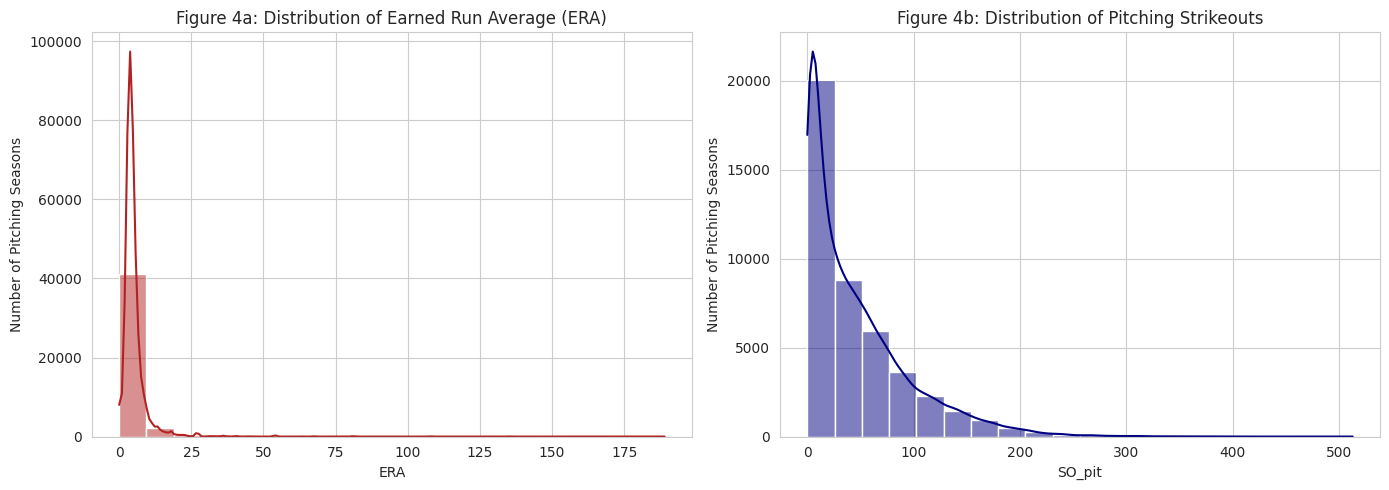

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

features = ["ERA", "SO_pit"]
titles = [
    "Figure 4a: Distribution of Earned Run Average (ERA)",
    "Figure 4b: Distribution of Pitching Strikeouts"
]
colors = ["firebrick", "navy"]

for ax, feature, title, color in zip(axes, features, titles, colors):
    sns.histplot(
        data=baseball.dropna(subset=[feature]),
        x=feature,
        bins=20,
        kde=True,
        color=color,
        ax=ax
    )

    ax.set_title(title)
    ax.set_xlabel(feature)
    ax.set_ylabel("Number of Pitching Seasons")

plt.tight_layout()
plt.show()

#####Summary

Again, we see more extreme skewness with ERA and pitching strikeouts - Figure 4. Overall, Figures 2-4 together show that most players are not playing much and are not being paid a lot. Each team has only a few highly paid players. This will need to be handled carefully as we model data and is a part of Hypothesis 2 below.

### Figure 5: Salary Distribution by Decade

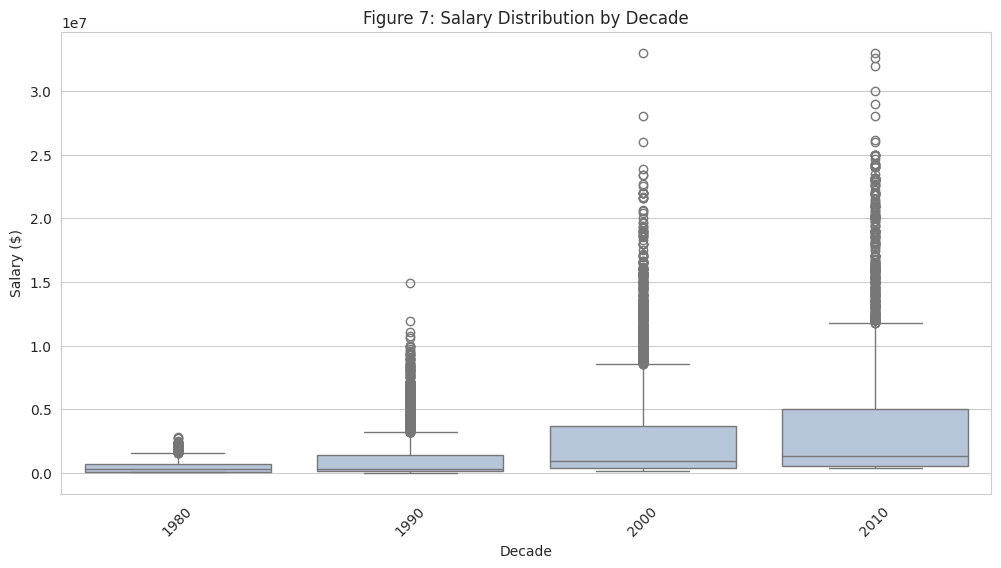

In [27]:
baseball["decade"] = (baseball["yearID"] // 10) * 10

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=baseball.dropna(subset=["salary"]),
    x="decade",
    y="salary",
    color="lightsteelblue"
)
plt.title("Figure 5: Salary Distribution by Decade")
plt.xlabel("Decade")
plt.ylabel("Salary ($)")
plt.xticks(rotation=45)
plt.show()

####Summary

We can clearly see that the median rises each decade and the spread across salaries does the same. What stands out is how the top salaries in each decade get farther from the stacked middle and it jumps in the 2010s.

###Figure 6: Home Runs vs. Salary

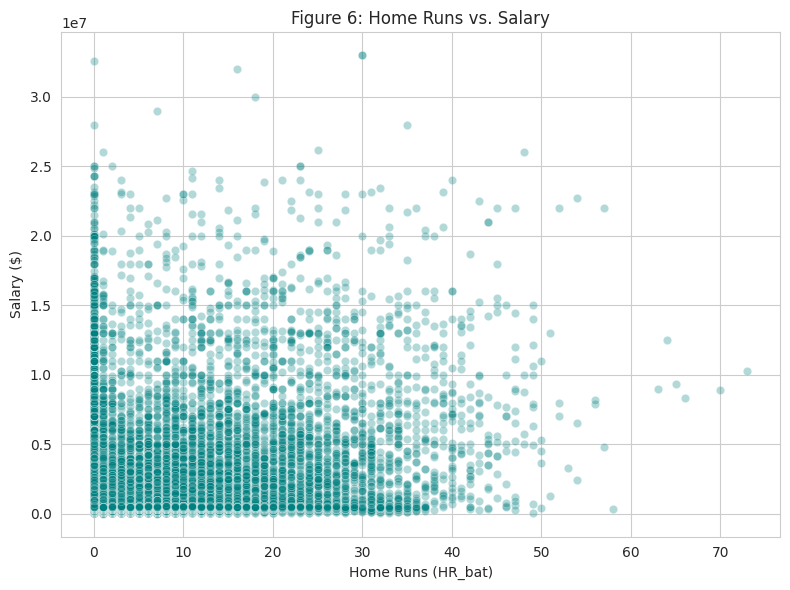

In [28]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=baseball.dropna(subset=["HR_bat", "salary"]),
    x="HR_bat",
    y="salary",
    alpha=0.3,
    color="teal"
)
plt.title("Figure 6: Home Runs vs. Salary")
plt.xlabel("Home Runs (HR_bat)")
plt.ylabel("Salary ($)")
plt.tight_layout()
plt.show()

####Summary

The data is interesting as it shows HRs do not mean you make the most money. Some of the highest salares are paid to people who get 0 homeruns.

# Hypothesis Generation

Again, we see more extreme skewness with ERA and Pitching Strikeouts. Overall, I think this shows that the vast majority of players aren't getting much playing time and are thus, not being paid much. In contrast each time probably has a few very highly paid players with high stats, so this will be important to consider in future modeling.

##Hypothesis 1:

We will have stronger predictive performance if we use two different moels to evaluate pithcers from non-pitching players.

**Supporting Evidence:**

Table 1 and Figure 1 show the pitching and batting data is stored in two different datasets which are very different in scope. We have merged them here, but we see an extreme amount of missing values that will likely hinder performance. If we inject 0s into these missing values or use an imputation approach we will likely inject too much noise into the dataset and make it unreliable. This also shows up in figure 5 homeruns vs salary as well.

**Why is this interesting?**

It is interesting because pithers and batters are likely evaluated on extremely different metrics, and they likely only have to proficient in one to make a high salary. Imputing missing values across roles could also inject misleading signal into the model.

**How will we evaluate it?**

We can build a model that is evaluated on the entire dataset with imputation strategies used for missing data. Additionally we will train two different models on the two different types of players and evaluate how these separate models perform.

##Hypothesis 2:

Log-transforming salary will yield better predictive performance.

**Supporting Evidence:**

Figures 2-4 and Table 2 show that Salary, like many other features, is extremely right-skewed which could have negative effects on predictive performance. If this isn't normalized the large outliers of the dataset will domiante the loss function and likely hinder performance.

**Why is this interesting?**

Skewness in the target variable tends to produce unreliable results, so this correction could improve performance.

**How will we evaluate it?**

We can train the model on both the raw target variable and the log-transformed data, and we can evaluate if the model improves with this transformation.

## Hypothesis 3:

Home runs have a weak association with salary at the low end, and are not a reliable predictor on their own when you use a combined dataset.

**Supporting Evidence:**

Figure 6 Home Run vs Salary shows a mild upward drift in the salary floor as home runs increase. This could be based on the hypothesis of seperating hitters and pitchers as the numbers are skeweed because so many players do not even hit. HR_bat is, at best, a weak and inconsistent individual predictor of salary once pitchers and low-playing-time seasons are mixed in.

**Why is this interesting?**

This is a case where the data pushes back against the assumption that "more home runs = more pay". It may also support seperating the dataset more.

**How we will evaluate it?**

We will compare feature importance on models that are trained on batters only vs. the full combined dataset, to test whether HR_bat's predictive power increases once role-mixing is removed.

## Reflection

The most interesting insight we discovered in EDA was that the data has extreme skewness, likely meaning that the majority of players don't make that much money and don't play that money (Figures 2-4). There are only a small number of stars that have high stats and make a lot of money, which may be more difficult to model.

We are most excited to evaluate hypothesis 1 to see how models are able to handle different player archetypes in predicting the same target variable. I predict that some models will be much more affected by this change, while some models will be able to handle it better and still be reliable on both types of players.

Yes, I think there will be some significant challenges with this data. First, there is a lot of missing values in many different features so we must figure out how to handle all of this. Additionally, we have players spanning decades which will obviously affect salaries a lot so we need to figure out how to represent this data best.

The most interesting insight we discovered in EDA was that the data has extreme skewness, likely meaning that the majority of players don't make that much money and don't play that much. There are only a small number of stars that have high stats and make a lot of money, which may be more difficult to model.

We are most excited to evaluate hypothesis 1 to see how models are able to handle different player archetypes in predicting the same target variable. I predict that some models will be much more affected by this change, while some models will be able to handle it better and still be reliable on both types of players.

I think there will be some significant challenges with this data.
- Missing Values - a large share of pitching and batting columns are missing for players who dont play that role (Table 1 and Figure 1).
- Era/Decade over time - the data set spans several decades of salary inflation shown in figure 5.
- Outliers and skewness - salary and most performance stats are right-skewed (Figures 2-4) which may require transformation.